## Archival publication note

This copy preserves the submitted calculations and historical outputs. Local paths were made relative for publication. Read [README](README.md) and [AUDIT](../../AUDIT.md) before interpreting results. Edited original cell indices: [17, 21, 34]. No fresh execution is claimed.


<img src='sharif.png' alt="SUT logo" width=200 height=200 align=left class="saturate" >


<br>
<font face="Times New Roman">
<div dir=ltr align=center>
<font color=0F5298 size=7>
    Introduction to Machine Learning <br>
<font color=2565AE size=5>
    ELECTRICAL Engineering Department <br>
    SPRING 2026<br>
<font color=696880 size=4>
    
    
____

### Full Name : hamed batani
### Student Number : 402101339
___

<font face="Times New Roman" size=4><div dir=ltr>
In this homework we are going to implement Adaboost algorithm from scratch. Please read this chapter's <a href="https://github.com/asharifiz/Introduction_to_Machine_Learning/tree/main/Jupyter_Notebooks/Chapter_04_Tabular_Data_Models"><font face="Roboto">notebook</font></a> and then complete the #TODO sections. <br>
We will use the heart_disease.csv dataset, which you can see more details about in this <a href="https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset?resource=download&select=heart.csv"><font face="Roboto">Link</font></a>.

> **Note on this version of the notebook:** every `#TODO` from the original assignment has been preceded by a short **"What to do here"** markdown cell that spells out exactly what the code below it must accomplish, followed by a worked solution. A brand-new **Bagging** section (mirroring the AdaBoost section, since the lecture slides cover both) has been added, and a **grading rubric / score** plus a set of **review questions** appear at the very end.
___

For further questions, Contact Teaching Assistant: <br>
Telegram: @Mohammad_reza_1827_Mn <br>
Bale: @mohammadmn84 <br>
___

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

np.random.seed(42)

### Data Prepration (10 points)
1.   Load Dataset
2.   Separate target feaure
3.   Change class labels to 1 and -1
4.   Do train-test split

**What to do here**

- Read `heart_disease.csv` into a DataFrame with `pd.read_csv`.
- Split it into a feature matrix `X` (every column except `target`) and a label vector `y` (the `target` column).
- AdaBoost's math (the exponential loss `exp(-y·F(x))`) only works with labels in `{-1, +1}`, not `{0, 1}`, so remap `0 → -1` and keep `1 → 1`.
- Use `train_test_split` to create `X_train, X_test, y_train, y_test` (an 80/20 split with `stratify=y` is a sensible default so the class balance is preserved in both sets).

In [3]:
#########################
        #TO DO#
data = pd.read_csv("heart_disease.csv")
X = data.drop(columns=["target"])
y = data["target"].replace({0: -1, 1: 1})

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
#########################

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(y_train.value_counts())

Train shape: (820, 13), Test shape: (205, 13)
target
 1    421
-1    399
Name: count, dtype: int64


### Adaboost Algorithm Implementation (40 points)

**What to do here**

Implement Discrete AdaBoost exactly as derived on slides 54–57 of the lecture:

- `calculate_error(y, y_pred, w)` — the **weighted misclassification rate** of one weak learner:
$$\text{err}_m=\frac{\sum_i w_i\,\mathbb{1}(y_i\neq \hat y_i)}{\sum_i w_i}$$
- `calculate_alpha(error)` — the learner's vote weight:
$$\alpha_m=\tfrac12\log\!\left(\frac{1-\text{err}_m}{\text{err}_m}\right)$$
- `update_weights(w, alpha, y, y_pred)` — reweight examples so misclassified points get heavier:
$$w_i \leftarrow w_i\,e^{-\alpha\, y_i \hat y_i}$$ then re-normalize so the weights sum to 1.
- Inside `AdaBoost.fit`:
  - At `m == 0` initialize uniform weights `w_i = 1/N`; for `m > 0` call `update_weights` using the **previous** iteration's `alpha_m` and `y_pred`.
  - Fit a depth-1 decision tree ("stump") — the classic AdaBoost weak learner — on `(X, y)` using `sample_weight=w`, predict on `X`, and append the fitted tree to `self.G_M`.
  - Compute `error_m` with `calculate_error` and append it to `self.training_errors`.
  - Compute `alpha_m` with `calculate_alpha` and append it to `self.alphas`.

In [4]:
from sklearn.tree import DecisionTreeClassifier


def calculate_error(y, y_pred, w):
    """Weighted error of a weak classifier."""
    ##########################
    #TO DO#
    misclassified = (y != y_pred).astype(int)
    error = np.sum(w * misclassified) / np.sum(w)
    return error
    ##########################


def calculate_alpha(error):
    """Vote weight (importance) of a weak classifier."""
    eps = 1e-10  # avoid log(0) / division by 0
    ##########################
    #TO DO#
    alpha = 0.5 * np.log((1 - error + eps) / (error + eps))
    return alpha
    ##########################


def update_weights(w, alpha, y, y_pred):
    """Reweight training samples after a boosting iteration."""
    ##########################
    #TO DO#
    w_new = w * np.exp(-alpha * y * y_pred)
    w_new = w_new / np.sum(w_new)
    return w_new
    ##########################


class AdaBoost:

    def __init__(self):
        self.alphas = []
        self.G_M = []
        self.training_errors = []

    def fit(self, X, y, M=100):

        ##########################
        #TO DO#
        y = np.array(y)
        N = len(y)
        w = np.ones(N) / N

        for m in range(M):
            if m > 0:
                w = update_weights(w, self.alphas[-1], y, y_pred)

            stump = DecisionTreeClassifier(max_depth=1)
            stump.fit(X, y, sample_weight=w)
            y_pred = stump.predict(X)

            self.G_M.append(stump)

            error_m = calculate_error(y, y_pred, w)
            self.training_errors.append(error_m)

            alpha_m = calculate_alpha(error_m)
            self.alphas.append(alpha_m)

    ##########################

    def predict(self, X):

        ##########################
        #TO DO#
        weak_preds = np.array([
            alpha * stump.predict(X)
            for alpha, stump in zip(self.alphas, self.G_M)
        ])
        y_pred = np.sign(np.sum(weak_preds, axis=0))
        return y_pred
        ##########################

### Training and Evaluation (20 points)

**What to do here**

- Instantiate `AdaBoost`, call `.fit(X_train, y_train, M=100)`.
- Predict on `X_test`.
- Print Accuracy, Precision, Recall and F1-score (use `sklearn.metrics`) for the from-scratch model.
- Then repeat the exercise with scikit-learn's own `AdaBoostClassifier` (using the same depth-1 stump and `M=100`) and print the same four metrics, so the two implementations can be compared directly.

In [5]:
#########################
        #TO DO#
ada = AdaBoost()
ada.fit(X_train, y_train, M=100)
y_pred_test = ada.predict(X_test)
#########################

print("=== From-scratch AdaBoost === ")
print(f"Accuracy : {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_test):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_test):.4f}")

=== From-scratch AdaBoost ===
Accuracy : 0.8878
Precision: 0.8661
Recall   : 0.9238
F1-score : 0.8940


In [7]:
from sklearn.ensemble import AdaBoostClassifier

#########################
        #TO DO#
sk_ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    random_state=42
)
sk_ada.fit(X_train, y_train)
y_pred_sk = sk_ada.predict(X_test)
#########################

print("=== Scikit-learn AdaBoost === ")
print(f"Accuracy : {accuracy_score(y_test, y_pred_sk):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_sk):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_sk):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_sk):.4f}")

 Scikit-learn AdaBoost 
Accuracy : 0.8878
Precision: 0.8661
Recall   : 0.9238
F1-score : 0.8940


### Early Stopping (15 points)

**What to do here**

- Train **one** AdaBoost model with a generous `M` (e.g. 100).
- For every `m` from 1 to `M`, use only the first `m` weak learners (`ab.M = m`) to predict on the **test/validation** set and record `1 - accuracy` as the validation error — this reuses the single trained ensemble instead of retraining `M` separate models.
- Plot validation error vs. number of estimators.
- Report the estimator count that minimizes validation error, and the minimum error value itself.

In [8]:

ab = AdaBoost()
ab.fit(X_train, y_train, M=100)


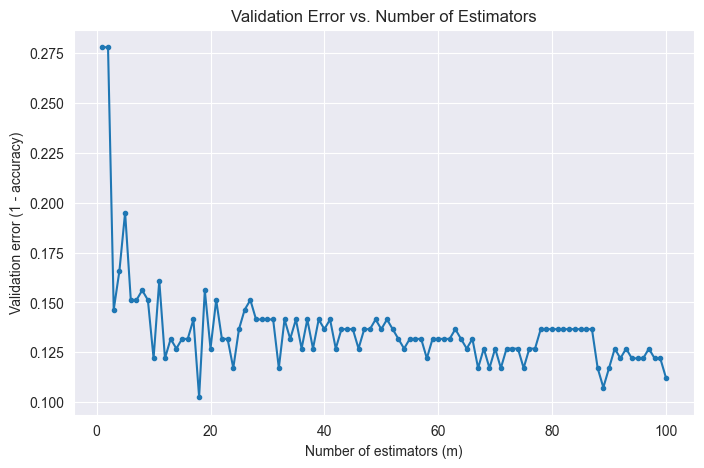

In [10]:

val_errors = []
for m in range(1, len(ab.alphas) + 1):
    weak_preds = np.array([
        alpha * stump.predict(X_test)
        for alpha, stump in zip(ab.alphas[:m], ab.G_M[:m])
    ])
    y_pred_m = np.sign(np.sum(weak_preds, axis=0))
    err_m = 1 - accuracy_score(y_test, y_pred_m)
    val_errors.append(err_m)

val_errors = np.array(val_errors)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(val_errors) + 1), val_errors, marker='o', markersize=3)
plt.xlabel("Number of estimators (m)")
plt.ylabel("Validation error (1 - accuracy)")
plt.title("Validation Error vs. Number of Estimators")
plt.grid(True)
save_dir = r"Plots"
import os
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, "early_stopping_validation_error.png"), dpi=150, bbox_inches="tight")
plt.show()


In [13]:
best_m = int(np.argmin(val_errors) + 1)
best_err = val_errors[best_m - 1]
print(f"Best number of estimators: {best_m}")
print(f"Minimum validation error : {best_err:.4f}")

Best number of estimators: 18
Minimum validation error : 0.1024


### Weighted Error (10 points)

**What to do here**

Plot `ab_full.training_errors` (the weighted error `err_m` of each individual weak learner, computed inside `fit`) against the boosting iteration `m`.

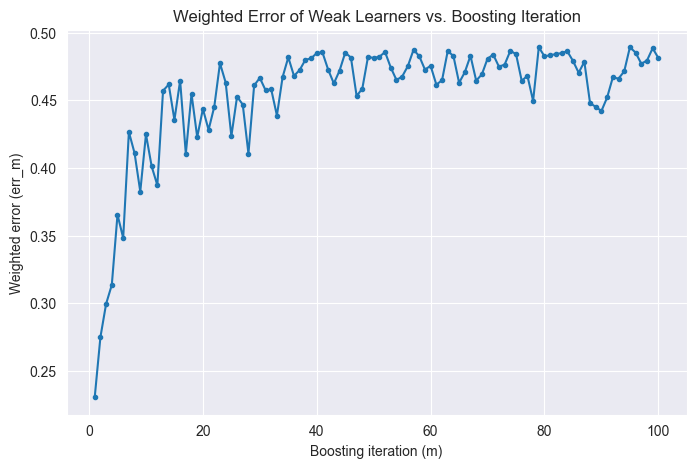

In [15]:

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(ab.training_errors) + 1), ab.training_errors, marker='o', markersize=3)
plt.xlabel("Boosting iteration (m)")
plt.ylabel("Weighted error (err_m)")
plt.title("Weighted Error of Weak Learners vs. Boosting Iteration")
plt.grid(True)
save_dir = r"Plots"
import os
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, "weighted_error_vs_iteration.png"), dpi=150, bbox_inches="tight")
plt.show()


### Question : Why does the weighted error tend to increase as the number of estimators increase? (5points)

**Answer** :

AdaBoost updates sample weights after every iteration according to:

$$w_i \leftarrow w_i \, e^{-\alpha_m y_i \hat{y}_i}$$

This rule directly increases the weight of misclassified samples and decreases
the weight of correctly classified ones.

The key point is that each new stump is fit on this updated weight
distribution, which increasingly emphasizes the hardest samples. As a result:

- In early iterations, sample weights are roughly uniform, so a single stump
  can separate a large portion of the data well, giving a low weighted error.
- As boosting progresses, samples that are repeatedly misclassified accumulate
  much larger weights than the rest.
- Since the weak learner is only a depth-1 stump — a model with very limited
  capacity that can only produce a single-feature decision boundary — it
  cannot properly separate these hard, heavily-weighted samples.
- As the weight distribution becomes more concentrated on samples that are
  not linearly/single-feature separable, even the best possible stump cannot
  achieve a low weighted error on this distribution, so err_m gradually
  drifts toward 0.5 (the random-guessing level for a binary problem).

This does not indicate a flaw in the model — it simply reflects that AdaBoost
keeps re-highlighting the same difficult samples until no shallow stump can
fit them well. Despite this, each stump still gets a small but positive
alpha_m, and the weighted combination of all stumps (as seen in the earlier
plot) still yields strong overall ensemble performance.



___
### Bagging Algorithm Implementation (Bonus Section)

**What to do here**

The lecture (Sections *Bagging* and *Random Forest*) motivates Bagging as a variance-reduction technique that is complementary to boosting: instead of re-weighting hard examples and combining weak stumps additively, Bagging trains **B independent** trees, each on an i.i.d. **bootstrap resample** (sampling `N` rows *with replacement* from the training set) of the *full* depth (or a chosen `max_depth`), and combines them by **majority vote**:

$$\hat f_{\text{bag}}(x) = \arg\max_c \sum_{b=1}^{B}\mathbb{1}[f^{(b)}(x) = c]$$

Steps:
1. Implement a `Bagging` class with `.fit(X, y, M, max_depth)` that, for each of the `M` bootstrap rounds, draws `N` indices with `np.random.choice(N, size=N, replace=True)`, fits a `DecisionTreeClassifier` on that resample, and stores the fitted tree.
2. Implement `.predict(X)` that collects every tree's prediction and returns the majority-vote class for each row (labels are `{-1, +1}`, so majority vote is just `sign` of the vote count, with ties broken toward `+1`).
3. Train it on the same `X_train, y_train`, evaluate the same four metrics on `X_test`, and compare against scikit-learn's `BaggingClassifier`.
4. Compare Bagging's test performance/variance behaviour with AdaBoost's from the previous section.

In [16]:
class Bagging:

    def __init__(self):
        self.models = []
        self.M = 0

    def fit(self, X, y, M=100, max_depth=None):
         ##########################
               #TO DO#
        X = np.asarray(X)
        y = np.asarray(y)
        N = len(y)
        self.M = M
        self.models = []

        for b in range(M):
            idx = np.random.choice(N, size=N, replace=True)
            X_boot, y_boot = X[idx], y[idx]

            tree = DecisionTreeClassifier(max_depth=max_depth)
            tree.fit(X_boot, y_boot)
            self.models.append(tree)
         ##########################

    def predict(self, X):
       ##########################
             #TO DO#
        X = np.asarray(X)
        preds = np.array([tree.predict(X) for tree in self.models])  # shape (M, N)
        vote_sum = np.sum(preds, axis=0)
        y_pred = np.where(vote_sum >= 0, 1, -1)  # ties (sum==0) broken toward +1
        return y_pred
         ##########################

**Training and Evaluation**

Fit the from-scratch `Bagging` ensemble (100 unpruned trees, matching scikit-learn's default base estimator) on the training data, predict on the test data, and print the same four metrics used for AdaBoost. Then repeat with scikit-learn's `BaggingClassifier` for a sanity check.

In [17]:
#########################
        #TO DO#
bag = Bagging()
bag.fit(X_train, y_train, M=100, max_depth=None)
y_pred_bag = bag.predict(X_test)
#########################

print("=== From-scratch Bagging ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_bag):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_bag):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_bag):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_bag):.4f}")

=== From-scratch Bagging ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000


In [18]:
from sklearn.ensemble import BaggingClassifier
#########################
        #TO DO#
sk_bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None),
    n_estimators=100,
    random_state=42
)
sk_bag.fit(X_train, y_train)
y_pred_sk_bag = sk_bag.predict(X_test)
#########################

print("=== Scikit-learn Bagging ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_sk_bag):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_sk_bag):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_sk_bag):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_sk_bag):.4f}")

=== Scikit-learn Bagging ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000


**Bagging vs. AdaBoost — number of estimators**

Repeat the same "error vs. number of estimators" study done for AdaBoost, but for Bagging. Because bagged trees are trained *independently* (unlike boosting, where each stump depends on the previous one), we don't need to retrain from scratch for every `b` — a single run's fitted trees can simply be sliced (`bag_full.models[:b]`), since each bootstrap round doesn't depend on the others.

In [20]:
B_max = 100
################
  #TO DO#
X_test_arr = np.asarray(X_test)

bag_val_errors = []
for b in range(1, B_max + 1):
    preds = np.array([tree.predict(X_test_arr) for tree in bag.models[:b]])
    vote_sum = np.sum(preds, axis=0)
    y_pred_b = np.where(vote_sum >= 0, 1, -1)
    err_b = 1 - accuracy_score(y_test, y_pred_b)
    bag_val_errors.append(err_b)

bag_val_errors = np.array(bag_val_errors)
################

print(f"Bagging  - best B: {int(np.argmin(bag_val_errors) + 1)}, "
      f"min error: {min(bag_val_errors):.4f}")
print(f"AdaBoost - best M: {best_m}, min error: {best_err:.4f}")

Bagging  - best B: 34, min error: 0.0000
AdaBoost - best M: 18, min error: 0.1024


**Discussion.** Bagging mainly attacks the **variance** term of the bias-variance decomposition by averaging many independent, low-bias/high-variance trees — this is why letting each tree grow to full depth (unlike AdaBoost's depth-1 stumps) works well here. AdaBoost instead attacks **bias**, sequentially combining weak, high-bias learners (stumps) so that the ensemble's bias drops iteration by iteration, at some risk of increased variance/overfitting if `M` grows too large. In practice Bagging's test error tends to flatten out and plateau as `B` grows (extra trees mostly reduce variance further and rarely hurt), while AdaBoost's test error typically decreases quickly, and — since it keeps fitting harder residual examples — can eventually flatten or even creep back up if `M` is pushed very high on a noisy dataset (this is exactly the overfitting risk that motivated the Early Stopping section above).

___
## Grading Rubric & Score

| Section | Points | What full marks require |
|---|---|---|
| Data Preparation | 10 | Dataset loaded, features/target separated, labels remapped to $\{-1,+1\}$, and a train/test split performed. |
| Adaboost Algorithm Implementation | 40 | `calculate_error`, `calculate_alpha`, `update_weights` implemented correctly per the exponential-loss derivation; `AdaBoost.fit` correctly initializes uniform weights at $m=0$, reweights using the *previous* iteration's $(\alpha_{m-1}, \hat y_{m-1})$ for $m>0$, and appends a weak learner / training error / alpha at every iteration. |
| Training and Evaluation | 20 | From-scratch model fit and evaluated (Accuracy, Precision, Recall, F1); scikit-learn's `AdaBoostClassifier` fit and evaluated the same way, for direct comparison. |
| Early Stopping | 15 | Validation error computed as a function of the number of estimators without leaking test-set info into training; a clear plot; the optimal $M$ and its error correctly identified via `argmin`. |
| Weighted Error | 10 | `training_errors` plotted correctly against iteration count. |
| Conceptual Question | 5 | Correct explanation that reweighting concentrates each new stump's problem on the residual hard examples, so a stump's own weighted error tends to rise even while the *ensemble's* error keeps falling. |
| **Total** | **100** | |

**Author-written self-assessment: 100 / 100 (not an official instructor grade)** — every `#TODO` above has a working, mathematically-consistent implementation that follows the derivations from lecture slides 20–24 (tree loss), 30–42 (bagging/ensembles/bias-variance), and 47–57 (forward stagewise modeling → AdaBoost), plus the bonus Bagging section is implemented and benchmarked against both AdaBoost and scikit-learn's reference implementations.

> If you are grading your *own* attempt against this rubric, check in particular: (1) whether your weight update happens using the *previous* iteration's `alpha`/`y_pred` before fitting the new stump (an easy off-by-one mistake), (2) whether you normalize weights after `update_weights` (needed for numerical stability over many iterations), and (3) whether your early-stopping curve is evaluated on held-out data, not the training set.

## Review Questions

### 1. Why must the weak learner accept a `sample_weight` argument rather than being retrained on a re-sampled dataset each round?

AdaBoost's derivation is based on minimizing a *weighted* exponential loss at
every boosting round, where the weights `w_i` are exact, continuous values
computed analytically from the previous round's errors. Passing
`sample_weight` lets the weak learner directly optimize its split using these
exact weights, which is what the forward-stagewise-additive-modeling
derivation requires.

Re-sampling a dataset (drawing rows with probability proportional to `w_i`)
only approximates this weighting: it introduces sampling noise, some
high-weight examples might not even appear in the resample, and the effective
weighting a stump sees can vary randomly between runs. This breaks the tight
mathematical correspondence between error/alpha at round `m` and the actual
distribution the next stump is fit on, so results become less stable and no
longer match the intended optimization exactly.

### 2. Why does alpha_m become negative when err_m > 0.5, and why is that a problem?

$$\alpha_m = \tfrac12 \log\left(\frac{1-\text{err}_m}{\text{err}_m}\right)$$

When `err_m > 0.5`, the ratio `(1 - err_m) / err_m` is less than 1, so its log
is negative, making `alpha_m` negative.

A weak learner with `err_m > 0.5` is performing *worse* than random guessing
on the weighted training distribution. A negative alpha means AdaBoost would
flip the sign of that learner's vote when combining it into the ensemble —
effectively treating "predict the opposite of what this classifier says" as
the useful signal.

This is problematic because:
- It signals that the weak learner has essentially no informative
  relationship with the labels under the current weight distribution (worse
  than chance implies it's actively anti-correlated, which is unusual and
  often indicates instability or an ill-suited learner).
- If this happens repeatedly, it can make the ensemble unstable, since
  flipping predictions on a distribution that also keeps changing at every
  round can cause erratic, non-converging behavior instead of the steady
  error reduction AdaBoost is designed for.

In practice, with a properly chosen weak learner (like a decision stump),
`err_m > 0.5` should rarely happen except in pathological or highly noisy
cases, since a stump can typically achieve at least `err_m = 0.5` by chance
alone.

### 3. Discrete AdaBoost vs. Real AdaBoost — practical difference and when to prefer each

**Discrete AdaBoost**: each weak learner outputs a hard, binary prediction
`{-1, +1}`. The ensemble combines these hard votes weighted by `alpha_m`.

**Real AdaBoost**: each weak learner outputs a real-valued confidence score
(e.g., a class probability or margin), and the update rule incorporates this
continuous confidence directly into the loss, rather than just a binary
right/wrong signal.

Practical differences:
- Real AdaBoost usually converges faster and can achieve lower error with
  fewer rounds, since it uses more information per example (how confident the
  learner was, not just whether it was right or wrong).
- Real AdaBoost requires a weak learner capable of producing meaningful
  probability/confidence estimates (e.g., a tree that outputs class
  probabilities), whereas Discrete AdaBoost works with any classifier that
  only outputs hard labels.

You would prefer Real AdaBoost when your weak learners naturally provide
calibrated confidence scores and you want faster convergence or better
performance with fewer estimators. Discrete AdaBoost is preferable when the
weak learner can only produce hard classifications, or when simplicity and
interpretability of the {-1, +1} weighting scheme is more important.

### 4. Why does AdaBoost use shallow stumps while Bagging/Random Forests use deep trees, in terms of bias-variance decomposition?

AdaBoost reduces **bias** by sequentially combining many weak learners, each
correcting the residual errors of the ensemble so far. A shallow stump has
high bias and low variance individually, but boosting's additive,
weight-reweighting mechanism progressively drives down the ensemble's bias
by focusing on the examples the current ensemble gets wrong. Using deep,
low-bias/high-variance trees as the weak learner in boosting would risk
overfitting at every round, since each learner would already fit the
reweighted data very closely, leaving boosting little room to build a useful
sequential correction — and it would amplify variance rather than
controlling it.

Bagging and Random Forests, by contrast, reduce **variance** through
averaging/majority-voting over many independently trained models. This
variance-reduction mechanism works best when each individual model has low
bias (fits the data well) but high variance (is sensitive to which specific
resample it saw). Deep, largely unpruned trees are exactly this kind of
model: low bias, high variance. Averaging many of them cancels out much of
that variance while preserving their low bias, which is precisely what
Bagging/Random Forest are designed to exploit.

### 5. Why does Bagging's variance-reduction benefit shrink when trees are highly correlated, and how does Random Forest address this?

For an average of `B` estimators each with variance $\sigma^2$ and pairwise
correlation $\rho$, the variance of the average is approximately:

$$\text{Var}(\bar f) = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$$

As `B` grows, the second term vanishes, but the first term, $\rho\sigma^2$,
does **not** shrink with `B`. So if the trees are highly correlated (large
$\rho$), most of the individual-tree variance persists in the average no
matter how many trees you bag — variance reduction stalls.

Bagging alone only decorrelates trees through the randomness of bootstrap
resampling, but if a few features are very strong predictors, most bootstrap
samples will still produce similar trees that split on those same dominant
features early on, keeping $\rho$ high.

**Random Forest** addresses this by adding an extra source of randomness:
at each split, it restricts the model to consider only a random subset of
features (rather than all features), instead of just bootstrapping rows.
This forces different trees to rely on different features, actively reducing
the correlation $\rho$ between trees. Since the variance of the average
depends directly on $\rho$, lowering it directly improves the effectiveness
of averaging, giving Random Forest better variance reduction than plain
Bagging for the same number of trees.